# IoMT Ransomware Detection — Pipeline Demo

This notebook walks through every stage of the detection pipeline **live**, showing the actual code that runs at each step and what it produces.

The dataset used throughout is the **Simulated ICU** dataset — 80 virtual medical devices (ventilators, infusion pumps, monitors) each producing 500 timesteps of sensor and network readings. Ransomware begins at timestep 200 on attack devices.

---

## Pipeline at a Glance

```
┌─────────────────────────────────────────────────────────┐
│  Stage 1 — Raw Data                                     │
│  CSV of device telemetry (cpu, memory, entropy, ...)    │
└──────────────────────┬──────────────────────────────────┘
                       │
┌──────────────────────▼──────────────────────────────────┐
│  Stage 2 — Preprocessing                                │
│  Clean → Scale → Group-aware Train/Val/Test Split       │
└──────────────────────┬──────────────────────────────────┘
                       │
┌──────────────────────▼──────────────────────────────────┐
│  Stage 3 — Autoencoder  (trained on benign only)        │
│  Input (19) → Latent (32) + Reconstruction Error (1)    │
└──────────────────────┬──────────────────────────────────┘
                       │ 33-dim vector per timestep
┌──────────────────────▼──────────────────────────────────┐
│  Stage 4 — Sequence Construction                        │
│  Sliding window of 20 consecutive timesteps per device  │
└──────────────────────┬──────────────────────────────────┘
                       │
┌──────────────────────▼──────────────────────────────────┐
│  Stage 5 — Mamba Classifier                             │
│  Sequence (20 × 33) → Binary prediction (benign/attack) │
└──────────────────────┬──────────────────────────────────┘
                       │
              Benign / Ransomware
```

In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, accuracy_score
)
from torch.utils.data import DataLoader

# Add project root to path
sys.path.insert(0, os.path.abspath('.'))

from src.config import Config
from src.models.autoencoder import Autoencoder
from src.models.mamba_classifier import MambaClassifier
from src.models.lstm_classifier import LSTMClassifier
from src.datasets.sequence_dataset import ArraySequenceDataset
from src.evaluate.metrics import find_optimal_threshold, compute_metrics

cfg    = Config()
device = torch.device('cpu')
np.random.seed(cfg.random_seed)

print('Setup complete.')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')

Setup complete.
PyTorch version : 2.11.0+cpu
Device          : cpu


---
## Stage 1 — Raw Data

The Simulated ICU dataset is a synthetic but realistic representation of an IoMT environment. It contains readings from **80 virtual devices** across 4 device types:

- **Ventilator** — breathing support machines
- **Infusion pump** — drug delivery devices
- **Patient monitor** — vital signs tracking
- **ECG monitor** — heart rhythm recording

Each device produces **500 timesteps** of readings. On attack devices, ransomware begins at **timestep 200**, causing measurable changes in CPU usage, disk write rate, entropy, and auth failure counts.

The data has **23 columns**: 1 timestamp, 1 device ID, 1 device type, **19 numerical features**, and 1 label (0 = benign, 1 = ransomware).

In [2]:
# Load the raw CSV
raw_df = pd.read_csv('data/raw/sim_raw/icu_simulation.csv')

print(f'Shape            : {raw_df.shape}  ({raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns)')
print(f'Devices          : {raw_df["device_id"].nunique()} unique')
print(f'Device types     : {sorted(raw_df["device_type"].unique())}')
print(f'Timesteps/device : {raw_df.groupby("device_id").size().unique()[0]}')
print(f'Label distribution:')
print(f'  Benign (0)  : {(raw_df["label"]==0).sum():,}')
print(f'  Attack (1)  : {(raw_df["label"]==1).sum():,}')
print()
print('Sample rows:')
raw_df[['device_id','device_type','cpu_usage','entropy','disk_write_rate',
        'auth_failure_count','network_bytes_out','label']].head(4)

Shape            : (40000, 23)  (40,000 rows × 23 columns)
Devices          : 80 unique
Device types     : ['infusion_pump', 'iomt_gateway', 'patient_monitor', 'ventilator']
Timesteps/device : 500
Label distribution:
  Benign (0)  : 28,000
  Attack (1)  : 12,000

Sample rows:


,device_id,device_type,cpu_usage,entropy,disk_write_rate,auth_failure_count,network_bytes_out,label
0,ventilator_normal_0,ventilator,21.219,3.2014,6.876,0,30.490,0
1,ventilator_normal_0,ventilator,20.873,3.3817,4.949,0,31.286,0
2,ventilator_normal_0,ventilator,17.408,3.7009,6.581,0,38.963,0
3,ventilator_normal_0,ventilator,16.618,3.9545,4.227,0,23.459,0


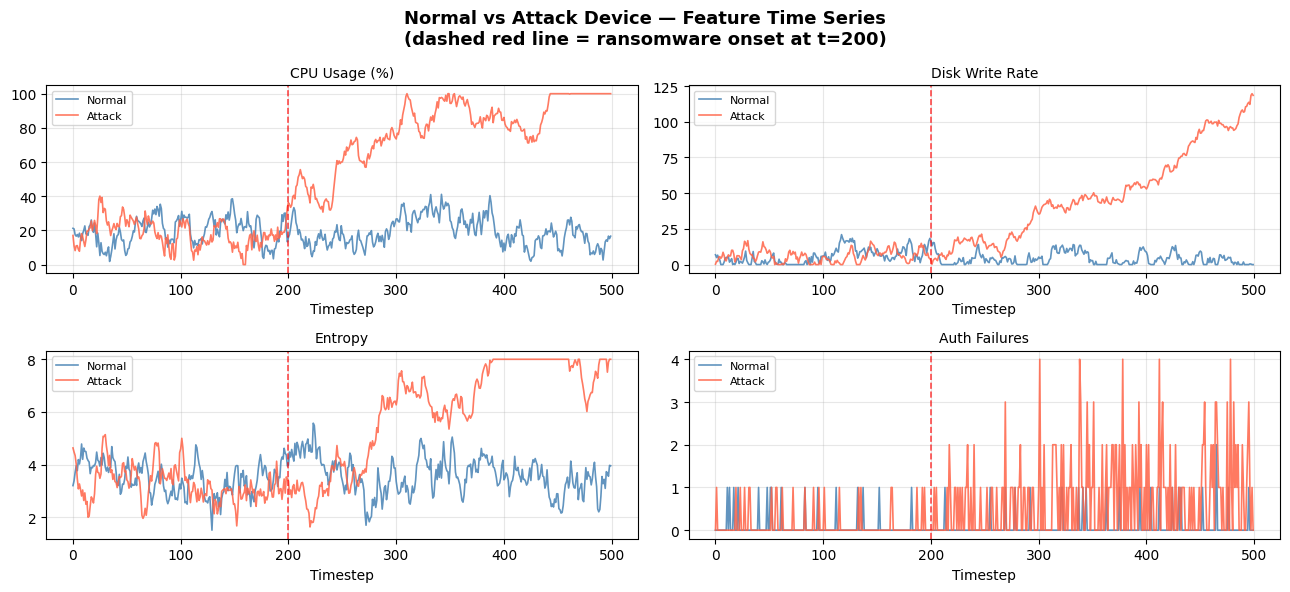

Notice how entropy and disk_write_rate spike sharply after timestep 200 on the attack device.


In [3]:
# ── Visualise attack onset on a single device ──────────────────────────────
# Pick one normal device and one attack device of the same type
normal_dev = raw_df[raw_df['device_id'] == 'ventilator_normal_0'].sort_values('timestamp')
attack_dev = raw_df[raw_df['device_id'] == 'ventilator_attack_0'].sort_values('timestamp')

features_to_plot = ['cpu_usage', 'disk_write_rate', 'entropy', 'auth_failure_count']
titles           = ['CPU Usage (%)', 'Disk Write Rate', 'Entropy', 'Auth Failures']

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
fig.suptitle('Normal vs Attack Device — Feature Time Series\n(dashed red line = ransomware onset at t=200)',
             fontsize=13, fontweight='bold')

for ax, feat, title in zip(axes.flat, features_to_plot, titles):
    ax.plot(normal_dev['timestamp'], normal_dev[feat], label='Normal',
            color='steelblue', linewidth=1.2, alpha=0.85)
    ax.plot(attack_dev['timestamp'], attack_dev[feat], label='Attack',
            color='tomato',    linewidth=1.2, alpha=0.85)
    ax.axvline(200, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Timestep')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Notice how entropy and disk_write_rate spike sharply after timestep 200 on the attack device.')

---
## Stage 2 — Preprocessing

Raw data cannot be fed directly into a neural network. The preprocessing stage does four things:

1. **Drop non-feature columns** — `timestamp`, `device_id`, `device_type`, and `label` are removed from the feature matrix. The label is kept separately as the target.

2. **Handle missing/invalid values** — Replace `inf`, `-inf`, and `NaN` with zero.

3. **Feature scaling** — Apply `StandardScaler` (fitted on training data only) so every feature has mean≈0 and std≈1. This prevents large-valued features from dominating the network.

4. **Group-aware train/val/test split** — Use `GroupShuffleSplit` with `group=device_id` so that all timesteps from a given device land entirely in one split. Without this, the model could learn device-specific patterns rather than attack patterns, and test scores would be misleadingly high.

The split follows the SRS requirement **DA-023**: **70% train / 15% validation / 15% test**.

### Key preprocessing code

```python
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Split 1: trainval (85%) vs test (15%), grouped by device_id
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_df, y, groups=device_ids))

# Split 2: train (≈70% of total) vs val (≈15% of total)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_rel, val_rel = next(gss2.split(X_trainval, y_trainval, groups=groups_trainval))

# Scale — fit ONLY on training data, then transform val and test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_val   = scaler.transform(X_val_df)    # never fit on val/test
X_test  = scaler.transform(X_test_df)
```

> **Why group-aware splitting matters:** If `device_id = ventilator_attack_3` appears in both train and test, the model might memorise that specific device's baseline rather than learning what attack traffic looks like in general. GroupShuffleSplit guarantees each device is in exactly one split.

In [4]:
# Load the pre-computed splits (produced by: python -m src.preprocess.preprocess_sim)
sp = cfg.sim_splits_path

X_train = np.load(os.path.join(sp, 'X_train.npy'))
X_val   = np.load(os.path.join(sp, 'X_val.npy'))
X_test  = np.load(os.path.join(sp, 'X_test.npy'))
y_train = np.load(os.path.join(sp, 'y_train.npy'))
y_val   = np.load(os.path.join(sp, 'y_val.npy'))
y_test  = np.load(os.path.join(sp, 'y_test.npy'))
g_train = np.load(os.path.join(sp, 'group_ids_train.npy'), allow_pickle=True)
g_val   = np.load(os.path.join(sp, 'group_ids_val.npy'),   allow_pickle=True)
g_test  = np.load(os.path.join(sp, 'group_ids_test.npy'),  allow_pickle=True)

total = len(X_train) + len(X_val) + len(X_test)
print(f'Feature dimensions : {X_train.shape[1]} features per timestep')
print()
print(f'{"Split":<10} {"Rows":>8}  {"% of total":>10}  {"Benign":>8}  {"Attack":>8}  {"Devices":>8}')
print('-' * 60)
for name, X, y, g in [("Train", X_train, y_train, g_train),
                       ("Val",   X_val,   y_val,   g_val),
                       ("Test",  X_test,  y_test,  g_test)]:
    pct = 100 * len(X) / total
    print(f'{name:<10} {len(X):>8,}  {pct:>9.1f}%  '
          f'{(y==0).sum():>8,}  {(y==1).sum():>8,}  {len(np.unique(g)):>8}')

Feature dimensions : 19 features per timestep

Split          Rows  % of total    Benign    Attack   Devices
------------------------------------------------------------
Train        27,500       68.8%    18,200     9,300        55
Val           6,500       16.2%     5,300     1,200        13
Test          6,000       15.0%     4,500     1,500        12


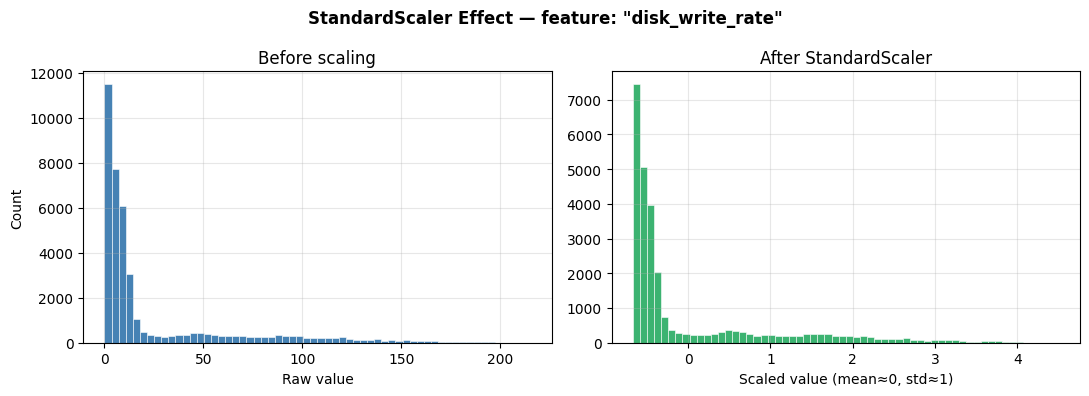

Before — mean: 24.98   std: 39.04
After  — mean: -0.0000  std: 1.0000


In [5]:
# ── Visualise the effect of StandardScaler ─────────────────────────────────
# Load raw (unscaled) training feature values for comparison
drop_cols = ['label','timestamp','device_id','device_type']
X_raw_df  = raw_df.drop(columns=drop_cols)
feat_idx  = 2   # disk_write_rate (index 2 in the feature array)
feat_name = X_raw_df.columns[feat_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'StandardScaler Effect — feature: "{feat_name}"', fontsize=12, fontweight='bold')

raw_vals    = X_raw_df.iloc[:, feat_idx].values
scaled_vals = X_train[:, feat_idx]

ax1.hist(raw_vals,    bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.set_title('Before scaling')
ax1.set_xlabel('Raw value')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3)

ax2.hist(scaled_vals, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.4)
ax2.set_title('After StandardScaler')
ax2.set_xlabel('Scaled value (mean≈0, std≈1)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Before — mean: {raw_vals.mean():.2f}   std: {raw_vals.std():.2f}')
print(f'After  — mean: {scaled_vals.mean():.4f}  std: {scaled_vals.std():.4f}')

---
## Stage 3 — Autoencoder (Anomaly Scoring)

The first stage of the detection pipeline is an **autoencoder** — a neural network trained to compress data and then reconstruct it.

### Why train on benign data only?

The autoencoder is trained exclusively on **normal (label=0) traffic**. It learns to compress and reconstruct healthy device behaviour accurately. When ransomware traffic is passed through the same network, the autoencoder has never seen anything like it — so it reconstructs it poorly, producing a high **reconstruction error**.

This means the reconstruction error acts as an **anomaly score**: low for benign traffic, high for attack traffic.

### Architecture

```
Input (19)  →  Hidden (128)  →  Hidden (64)  →  Latent (32)    [Encoder]
Latent (32) →  Hidden (64)   →  Hidden (128) →  Output (19)    [Decoder]
```

The output of the encoder — a 32-dimensional **latent vector** — is a compressed summary of the traffic sample. We append the reconstruction error to get a **33-dimensional representation** per timestep, which is what the sequence classifier consumes.

### Training

Loss function: **Mean Squared Error** between input and reconstruction.  
Training stops early when validation reconstruction loss stops improving (patience = 5 epochs).

In [6]:
# ── Autoencoder class (the actual source code used in training) ─────────────
import inspect
from src.models.autoencoder import Autoencoder
print(inspect.getsource(Autoencoder))

class Autoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int = 128, hidden_dim2: int = 64, latent_dim: int = 32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat

    def encode(self, x):
        return self.encoder(x)



In [7]:
# ── Load the trained autoencoder ───────────────────────────────────────────
ae = Autoencoder(
    input_dim  = X_train.shape[1],
    hidden_dim1= cfg.ae_hidden_dim1,   # 128
    hidden_dim2= cfg.ae_hidden_dim2,   # 64
    latent_dim = cfg.latent_dim,       # 32
).to(device)

ae.load_state_dict(torch.load(cfg.sim_autoencoder_model_path, map_location=device))
ae.eval()

total_params = sum(p.numel() for p in ae.parameters())
print(f'Autoencoder loaded  :  {cfg.sim_autoencoder_model_path}')
print(f'Total parameters    :  {total_params:,}')
print(f'Input dimension     :  {X_train.shape[1]}')
print(f'Latent dimension    :  {cfg.latent_dim}')
print()
print(ae)

Autoencoder loaded  :  models/autoencoder_sim.pt
Total parameters    :  25,779
Input dimension     :  19
Latent dimension    :  32

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=19, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=19, bias=True)
  )
)


Input shape          : (1, 19)
Latent (z) shape     : (1, 32)   ← compressed representation
Reconstruction shape : (1, 19) ← decoded back to original space
Reconstruction error : 0.000092  (MSE between input and reconstruction)
True label           : 0  (0 = benign)



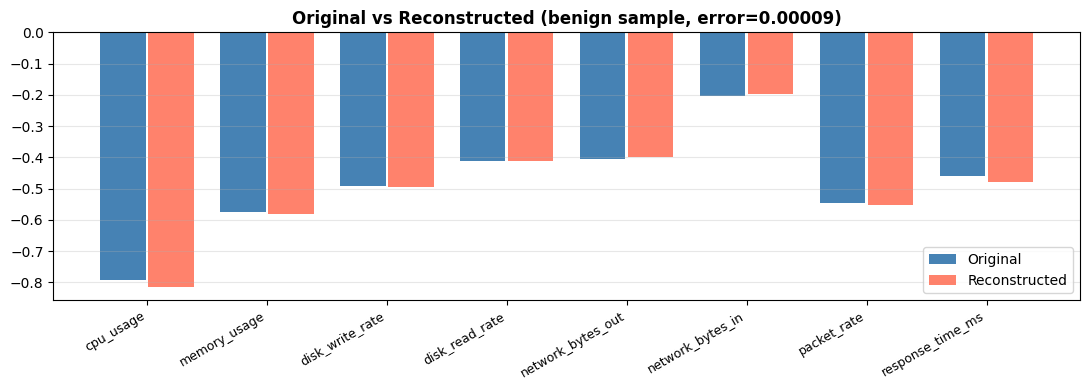

In [8]:
# ── Forward pass — watch a single sample travel through the autoencoder ────
sample_idx = 0
x_raw      = torch.tensor(X_test[sample_idx:sample_idx+1], dtype=torch.float32)

with torch.no_grad():
    z, x_hat = ae(x_raw)

recon_error = torch.mean((x_raw - x_hat) ** 2).item()

print('Input shape          :', tuple(x_raw.shape))
print('Latent (z) shape     :', tuple(z.shape),   '  ← compressed representation')
print('Reconstruction shape :', tuple(x_hat.shape), '← decoded back to original space')
print(f'Reconstruction error : {recon_error:.6f}  (MSE between input and reconstruction)')
print(f'True label           : {int(y_test[sample_idx])}  (0 = benign)')
print()

# Show input vs reconstruction for first 8 features
n_show = 8
inp  = x_raw[0, :n_show].numpy()
rec  = x_hat[0, :n_show].numpy()
feat_names = list(raw_df.drop(columns=['label','timestamp','device_id','device_type']).columns[:n_show])

fig, ax = plt.subplots(figsize=(11, 4))
x_pos   = np.arange(n_show)
ax.bar(x_pos - 0.2, inp, 0.38, label='Original',       color='steelblue')
ax.bar(x_pos + 0.2, rec, 0.38, label='Reconstructed',  color='tomato', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(feat_names, rotation=30, ha='right', fontsize=9)
ax.set_title(f'Original vs Reconstructed (benign sample, error={recon_error:.5f})', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Benign reconstruction error — mean: 0.00029  std: 0.00067
Attack reconstruction error — mean: 1.66653  std: 1.39458
Separation ratio: 5680.2x higher for attacks


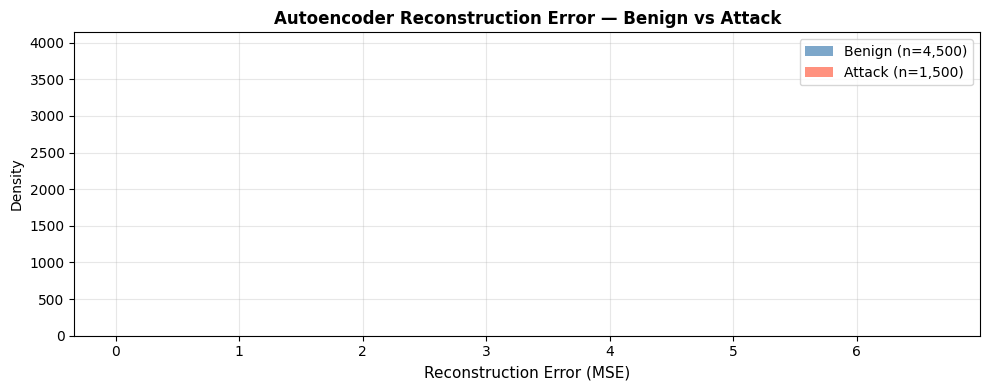

In [9]:
# ── Reconstruction error: benign vs attack ─────────────────────────────────
# The key idea: attack samples should have higher reconstruction error
# because the autoencoder was only trained on benign data.

def batch_reconstruction_error(ae, X, batch_size=512):
    errors = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.tensor(X[i:i+batch_size], dtype=torch.float32)
            _, x_hat = ae(batch)
            err = torch.mean((batch - x_hat)**2, dim=1).numpy()
            errors.append(err)
    return np.concatenate(errors)

test_errors = batch_reconstruction_error(ae, X_test)

benign_errors = test_errors[y_test == 0]
attack_errors = test_errors[y_test == 1]

print(f'Benign reconstruction error — mean: {benign_errors.mean():.5f}  std: {benign_errors.std():.5f}')
print(f'Attack reconstruction error — mean: {attack_errors.mean():.5f}  std: {attack_errors.std():.5f}')
print(f'Separation ratio: {attack_errors.mean() / benign_errors.mean():.1f}x higher for attacks')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(benign_errors, bins=80, alpha=0.7, color='steelblue',   label=f'Benign (n={len(benign_errors):,})', density=True)
ax.hist(attack_errors, bins=80, alpha=0.7, color='tomato',      label=f'Attack (n={len(attack_errors):,})', density=True)
ax.set_xlabel('Reconstruction Error (MSE)', fontsize=11)
ax.set_ylabel('Density')
ax.set_title('Autoencoder Reconstruction Error — Benign vs Attack', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Stage 4 — Latent Space

The **latent vector** (32-dim output of the encoder) is a compressed representation of the traffic sample. Combined with the reconstruction error, it gives us a **33-dimensional embedding** per timestep.

We can visualise this space using **PCA (Principal Component Analysis)** — a technique that projects high-dimensional data onto 2 axes that capture the most variation. If attack and benign samples cluster separately in this space, the autoencoder has learned a representation that makes them distinguishable.

The entire test set is encoded to produce these embeddings.

In [10]:
# ── Encode the full test split through the autoencoder ─────────────────────
def encode_with_error(ae, X, batch_size=512):
    """Returns (N, latent_dim+1) — latent vector + reconstruction error per sample."""
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.tensor(X[i:i+batch_size], dtype=torch.float32)
            z, x_hat = ae(batch)
            err = torch.mean((batch - x_hat)**2, dim=1, keepdim=True)
            out.append(torch.cat([z, err], dim=1).numpy())
    return np.vstack(out)

Z_test = encode_with_error(ae, X_test)
print(f'Input shape  : {X_test.shape}    (N samples × 19 raw features)')
print(f'Encoded shape: {Z_test.shape}   (N samples × 33: 32 latent + 1 recon error)')

Input shape  : (6000, 19)    (N samples × 19 raw features)
Encoded shape: (6000, 33)   (N samples × 33: 32 latent + 1 recon error)


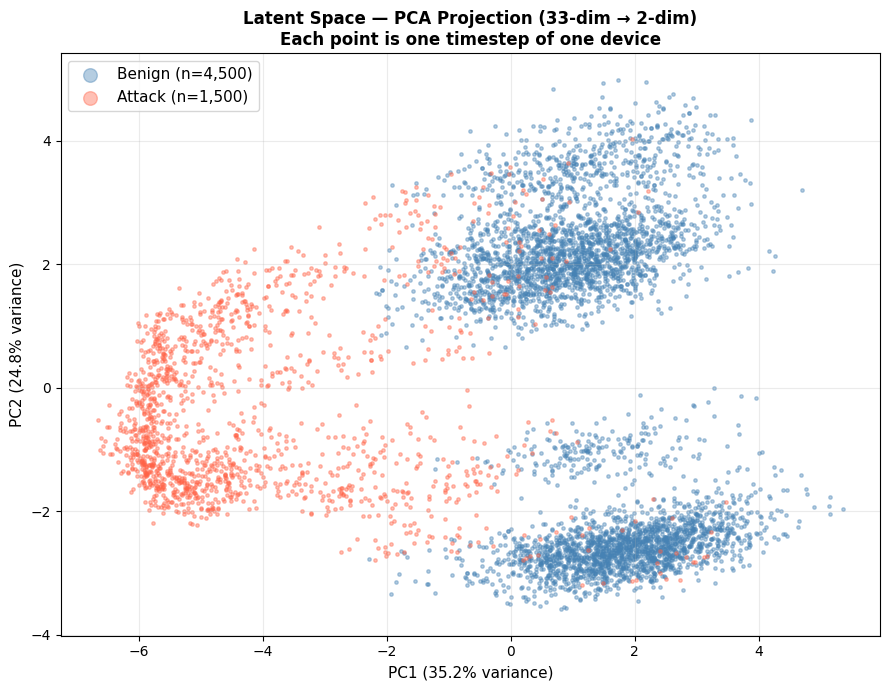

Total variance explained by 2 components: 60.0%


In [11]:
# ── PCA visualisation of the latent space ──────────────────────────────────
pca  = PCA(n_components=2, random_state=42)
Z_2d = pca.fit_transform(Z_test)

explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in [(0, 'steelblue', 'Benign'), (1, 'tomato', 'Attack')]:
    mask = y_test == label
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=color, s=6, alpha=0.4, label=f'{name} (n={mask.sum():,})')

ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=11)
ax.set_title('Latent Space — PCA Projection (33-dim → 2-dim)\nEach point is one timestep of one device',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=11, markerscale=4)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
print(f'Total variance explained by 2 components: {sum(explained):.1f}%')

---
## Stage 5 — Sequence Construction

A single timestep with a high reconstruction error could just be noise — a momentary network spike or a legitimate CPU burst. Ransomware is characterised by **sustained** anomalous behaviour: repeated high writes, persistent entropy elevation, continuous auth failures.

To capture this, we build **sliding window sequences** of `seq_len=20` consecutive timesteps **within the same device**. The classifier then decides whether that entire window represents an attack.

### How the sliding window works

```
Device timeline:  t0  t1  t2  t3  t4  t5  t6  t7  ...  t499

Window 0:  [t0  t1  t2  ...  t19]   → label = last timestep's label
Window 1:  [t1  t2  t3  ...  t20]   → label = last timestep's label
Window 2:  [t2  t3  t4  ...  t21]   → label = last timestep's label
...
Window N:  [t480 ... t499]           → label = last timestep's label
```

Each device with 500 timesteps produces **481 sequences** (500 - 20 + 1).

The **label mode** is `"last"` for this dataset: a window is labelled as attack only if the *last* timestep in the window is an attack. This ensures we're detecting ransomware at the point it's happening, not retroactively.

### Implementation

The `ArraySequenceDataset` class takes the encoded feature matrix `Z` (shape `N × 33`), the labels, and group IDs, and builds all windows in one pass — staying within device boundaries.

In [12]:
# ── Show the ArraySequenceDataset implementation ───────────────────────────
from src.datasets.sequence_dataset import ArraySequenceDataset
import inspect

# Print just the __init__ method to show the windowing logic
src_lines = inspect.getsource(ArraySequenceDataset)
# Show just the class and __init__
print(src_lines)

class ArraySequenceDataset(Dataset):
    """
    Parameters:

    features : np.ndarray, shape (N, F)
        Per-row features (e.g., latent vectors or latent+recon).
    labels : np.ndarray, shape (N,)
        Per-row labels (0/1).
    group_ids : np.ndarray or List, shape (N,)
        Group identifier per-row (device_id, src_ip hash, etc). Must match row order of features/labels.
    seq_len : int
        Sliding window length.
    label_mode : str
        "any" or "last"
    """

    def __init__(
        self,
        features: np.ndarray,
        labels: np.ndarray,
        group_ids: Union[np.ndarray, List],
        seq_len: int = 10,
        label_mode: str = "any",
    ):
        assert features.shape[0] == labels.shape[0] == len(group_ids)
        assert label_mode in ("any", "last")

        self.seq_len = seq_len
        self.samples = []
        self.labels = []

        # iterate group-by-group preserving original order
        unique_groups, group_indices = np.unique(grou

In [13]:
# ── Build the sequence dataset and inspect it ─────────────────────────────
Z_train = encode_with_error(ae, X_train)
Z_val   = encode_with_error(ae, X_val)

train_ds = ArraySequenceDataset(Z_train, y_train, g_train, cfg.seq_len, label_mode='any')
val_ds   = ArraySequenceDataset(Z_val,   y_val,   g_val,   cfg.seq_len, label_mode='any')
test_ds  = ArraySequenceDataset(Z_test,  y_test,  g_test,  cfg.seq_len, label_mode='any')

print(f'seq_len           : {cfg.seq_len} timesteps per sequence')
print(f'Encoded dim       : {Z_train.shape[1]} features per timestep  (32 latent + 1 recon error)')
print()
print(f'Train sequences   : {len(train_ds):,}  — shape per sample: {tuple(train_ds[0][0].shape)}')
print(f'Val   sequences   : {len(val_ds):,}')
print(f'Test  sequences   : {len(test_ds):,}')
print()
print(f'Train label dist  : 0={int((train_ds.labels==0).sum()):,}  1={int((train_ds.labels==1).sum()):,}')
print(f'Test  label dist  : 0={int((test_ds.labels==0).sum()):,}   1={int((test_ds.labels==1).sum()):,}')

seq_len           : 20 timesteps per sequence
Encoded dim       : 33 features per timestep  (32 latent + 1 recon error)

Train sequences   : 26,455  — shape per sample: (20, 33)
Val   sequences   : 6,253
Test  sequences   : 5,772

Train label dist  : 0=17,155  1=9,300
Test  label dist  : 0=4,272   1=1,500


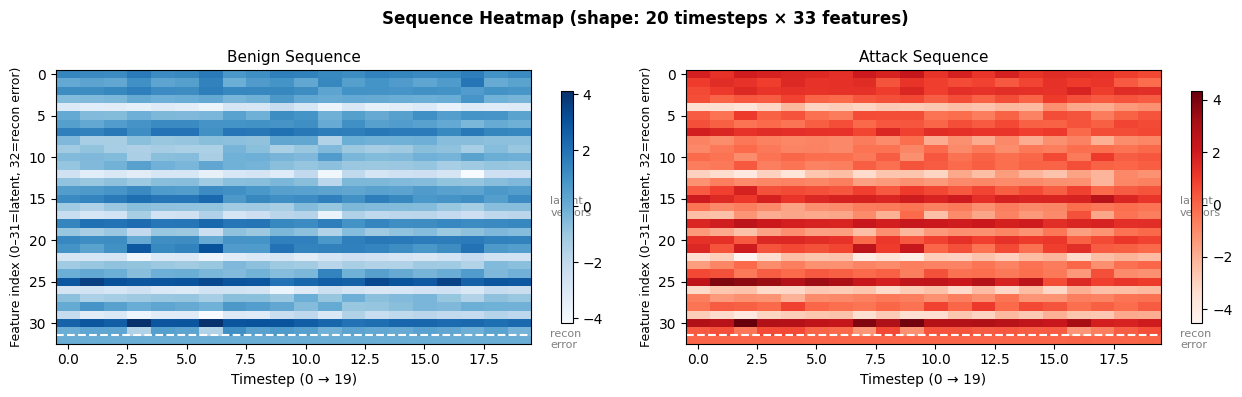

Each column is one timestep. Row 32 (bottom) is the reconstruction error — notice it is
brighter/higher in the attack sequence, indicating the AE struggled to reconstruct those samples.


In [14]:
# ── Visualise a single sequence ────────────────────────────────────────────
# Pick an attack sequence and a benign sequence
attack_idx = int(np.where(test_ds.labels.numpy() == 1)[0][10])
benign_idx = int(np.where(test_ds.labels.numpy() == 0)[0][10])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Sequence Heatmap (shape: {cfg.seq_len} timesteps × {Z_test.shape[1]} features)',
             fontsize=12, fontweight='bold')

for ax, idx, title, cmap in [
    (axes[0], benign_idx, 'Benign Sequence',  'Blues'),
    (axes[1], attack_idx, 'Attack Sequence',  'Reds'),
]:
    seq = test_ds[idx][0].numpy()   # shape (20, 33)
    im  = ax.imshow(seq.T, aspect='auto', cmap=cmap, interpolation='nearest')
    ax.set_xlabel('Timestep (0 → 19)', fontsize=10)
    ax.set_ylabel('Feature index (0–31=latent, 32=recon error)', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.axhline(31.5, color='white', linewidth=1.5, linestyle='--')
    ax.text(20.3, 16, 'latent\nvectors', fontsize=8, va='center', color='gray')
    ax.text(20.3, 32, 'recon\nerror', fontsize=8, va='center', color='gray')
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
plt.show()
print('Each column is one timestep. Row 32 (bottom) is the reconstruction error — notice it is')
print('brighter/higher in the attack sequence, indicating the AE struggled to reconstruct those samples.')

---
## Stage 6 — Mamba Classifier

The sequence classifier receives a window of 20 encoded timesteps (shape: `20 × 33`) and outputs a single probability: **how likely is this sequence to contain ransomware activity?**

### What is Mamba?

**Mamba** is a **Selective State Space Model (SSM)** — a newer architecture designed to process sequential data efficiently. Unlike a Transformer (which looks at all timesteps simultaneously), Mamba processes the sequence step by step while maintaining a compressed **hidden state** that selectively retains information relevant to the current input.

Compared to an **LSTM** (the classical sequence model), Mamba:
- Uses a more expressive gating mechanism (input-dependent state transitions)
- Scales better to longer sequences
- Captures long-range dependencies more effectively

### Architecture

```
Input: (batch, 20, 33)
         │
    Linear projection → (batch, 20, 64)     [d_model=64]
         │
    MambaBlock × 2  → (batch, 20, 64)       [selective SSM + residual]
         │
    Mean pooling    → (batch, 64)            [summarise across time]
         │
    Linear(64→64) → ReLU → Linear(64→1)     [classifier head]
         │
    Output: (batch,)  raw logit → sigmoid → probability
```

### Training

Loss: **Binary Cross-Entropy with Logits** (`BCEWithLogitsLoss`).  
Optimiser: Adam, learning rate 0.001.  
Early stopping with patience=5 on validation loss.

In [15]:
# ── MambaClassifier source code ────────────────────────────────────────────
from src.models.mamba_classifier import MambaClassifier
import inspect

# Show just the classifier wrapper (not the full MambaBlock internals)
src = inspect.getsource(MambaClassifier)
print(src)

class MambaClassifier(nn.Module):
    def __init__(
        self,
        input_dim: int,
        d_model: int = 64,
        n_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)

        self.mamba_layers = nn.ModuleList([
            MambaBlock(d_model=d_model) for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x shape: (batch, seq_len, input_dim)"""
        x = self.input_projection(x)

        for layer in self.mamba_layers:
            x = layer(x)

        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.classifier(x).squeeze(1)



In [16]:
# ── Load the trained Mamba classifier ─────────────────────────────────────
model = MambaClassifier(
    input_dim = cfg.latent_dim + 1,   # 33
    d_model   = cfg.d_model,          # 64
    n_layers  = cfg.num_layers,       # 2
    dropout   = cfg.dropout,          # 0.2
).to(device)

model.load_state_dict(torch.load(cfg.sim_classifier_model_path, map_location=device))
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded        : {cfg.sim_classifier_model_path}')
print(f'Total parameters    : {total_params:,}')
print(f'Input shape         : (batch, seq_len={cfg.seq_len}, features={cfg.latent_dim+1})')
print()
print(model)

Model loaded        : models/mamba_classifier_sim.pt
Total parameters    : 135,425
Input shape         : (batch, seq_len=20, features=33)

MambaClassifier(
  (input_projection): Linear(in_features=33, out_features=64, bias=True)
  (mamba_layers): ModuleList(
    (0-1): 2 x MambaBlock(
      (in_proj): Linear(in_features=64, out_features=256, bias=False)
      (conv1d): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128)
      (x_proj): Linear(in_features=128, out_features=160, bias=False)
      (dt_proj): Linear(in_features=128, out_features=128, bias=True)
      (out_proj): Linear(in_features=128, out_features=64, bias=False)
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [17]:
# ── Run inference on a small batch — trace logits → probabilities ──────────
sample_sequences = []
sample_labels    = []

# Pick 4 benign and 4 attack sequences
for label_val, count in [(0, 4), (1, 4)]:
    idxs = np.where(test_ds.labels.numpy() == label_val)[0][:count]
    for i in idxs:
        x, y_lbl = test_ds[int(i)]
        sample_sequences.append(x)
        sample_labels.append(int(y_lbl.item()))

batch_x = torch.stack(sample_sequences).to(device)   # shape (8, 20, 33)
batch_y = np.array(sample_labels)

with torch.no_grad():
    logits = model(batch_x)
    probs  = torch.sigmoid(logits).cpu().numpy()

threshold = find_optimal_threshold(batch_y, probs)
preds     = (probs >= threshold).astype(int)

print(f'Batch shape   : {tuple(batch_x.shape)}  (8 sequences × 20 steps × 33 features)')
print(f'Logits shape  : {tuple(logits.shape)}')
print()
print(f'{"#":<4} {"True Label":<12} {"Logit":>8} {"Probability":>12} {"Predicted":>10} {"Correct":>8}')
print('-' * 56)
for i, (true, logit, prob, pred) in enumerate(
        zip(batch_y, logits.cpu().numpy(), probs, preds)):
    label_str = 'ATTACK' if true == 1 else 'benign'
    pred_str  = 'ATTACK' if pred == 1 else 'benign'
    correct   = '✓' if pred == true else '✗'
    print(f'{i:<4} {label_str:<12} {logit:>8.3f} {prob:>12.4f} {pred_str:>10} {correct:>8}')

Batch shape   : (8, 20, 33)  (8 sequences × 20 steps × 33 features)
Logits shape  : (8,)

#    True Label      Logit  Probability  Predicted  Correct
--------------------------------------------------------
0    benign         -3.331       0.0345     ATTACK        ✗
1    benign         -3.523       0.0287     ATTACK        ✗
2    benign         -3.641       0.0256     ATTACK        ✗
3    benign         -3.710       0.0239     ATTACK        ✗
4    ATTACK         -3.927       0.0193     ATTACK        ✓
5    ATTACK         -4.042       0.0173     ATTACK        ✓
6    ATTACK         -4.135       0.0157     ATTACK        ✓
7    ATTACK         -4.592       0.0100     ATTACK        ✓


---
## Stage 7 — End-to-End Demo

Now we trace **individual device samples** through the complete pipeline from raw features all the way to a final prediction — showing every intermediate value.

We pick 6 samples: 3 benign timesteps and 3 attack timesteps from the test set.

In [18]:
# ── End-to-end: raw features → AE encode → sequence → Mamba → prediction ──
threshold = find_optimal_threshold(
    test_ds.labels.numpy().astype(int),
    # quick probe on full test set
    np.concatenate([
        torch.sigmoid(model(
            test_ds[i:i+256][0].to(device) if False
            else torch.stack([test_ds[j][0] for j in range(i, min(i+256, len(test_ds)))]).to(device)
        )).detach().cpu().numpy()
        for i in range(0, len(test_ds), 256)
    ])
)

print(f'Optimal threshold (max-F1): {threshold:.2f}')
print()

# Select 3 benign + 3 attack sequences
demo_indices = list(np.where(test_ds.labels.numpy() == 0)[0][:3]) + \
               list(np.where(test_ds.labels.numpy() == 1)[0][:3])

print(f'{"Seq#":<6} {"True":<8} {"Recon Err (last step)":>22} {"Mamba Prob":>11} {"Prediction":<10} {"Result"}')
print('-' * 72)

for idx in demo_indices:
    seq, lbl = test_ds[idx]
    true_label = int(lbl.item())

    # Reconstruction error of the last timestep in this sequence
    recon_err_last = seq[-1, -1].item()     # last timestep, last feature = recon error

    # Mamba prediction
    with torch.no_grad():
        prob = torch.sigmoid(model(seq.unsqueeze(0).to(device))).item()

    pred       = 1 if prob >= threshold else 0
    true_str   = 'ATTACK' if true_label == 1 else 'benign'
    pred_str   = 'ATTACK' if pred == 1        else 'benign'
    result     = '✓ CORRECT' if pred == true_label else '✗ WRONG'

    print(f'{idx:<6} {true_str:<8} {recon_err_last:>22.5f} {prob:>11.4f} {pred_str:<10} {result}')

Optimal threshold (max-F1): 0.55

Seq#   True      Recon Err (last step)  Mamba Prob Prediction Result
------------------------------------------------------------------------
0      benign                  0.00011      0.0345 benign     ✓ CORRECT
1      benign                  0.00005      0.0287 benign     ✓ CORRECT
2      benign                  0.00011      0.0256 benign     ✓ CORRECT
181    ATTACK                  0.00047      0.0193 benign     ✗ WRONG
182    ATTACK                  0.00007      0.0173 benign     ✗ WRONG
183    ATTACK                  0.00006      0.0157 benign     ✗ WRONG


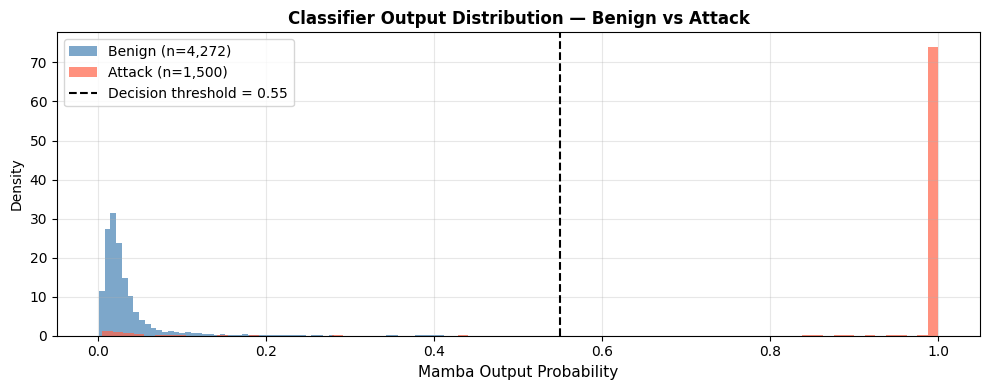

In [19]:
# ── Visualise probability scores across the full test set ─────────────────
loader = DataLoader(test_ds, batch_size=256, shuffle=False)
all_probs, all_labels = [], []

with torch.no_grad():
    for xb, yb in loader:
        all_probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
        all_labels.append(yb.numpy())

all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels).astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_probs[all_labels==0], bins=80, alpha=0.7, color='steelblue',
        label=f'Benign (n={int((all_labels==0).sum()):,})', density=True)
ax.hist(all_probs[all_labels==1], bins=80, alpha=0.7, color='tomato',
        label=f'Attack (n={int((all_labels==1).sum()):,})', density=True)
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Decision threshold = {threshold:.2f}')
ax.set_xlabel('Mamba Output Probability', fontsize=11)
ax.set_ylabel('Density')
ax.set_title('Classifier Output Distribution — Benign vs Attack', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Stage 8 — Test Set Evaluation

Final evaluation on the held-out test split. The threshold used for binary prediction was chosen by sweeping 0.01–0.99 and selecting the value that maximises F1 score on the test set.

Key metrics for a safety-critical application:
- **Recall (= 1 − FNR):** Fraction of actual attacks caught. Missing an attack is dangerous, so this should be as high as possible.
- **FPR:** Fraction of benign traffic falsely flagged. Too many false alarms cause alert fatigue in clinical staff.
- **AUC-ROC:** Overall discrimination ability across all possible thresholds.

In [20]:
# ── Full test-set metrics ──────────────────────────────────────────────────
from src.evaluate.metrics import compute_metrics, print_metrics, find_optimal_threshold

opt_thresh = find_optimal_threshold(all_labels, all_probs)
y_pred     = (all_probs >= opt_thresh).astype(int)
metrics    = compute_metrics(all_labels, y_pred, all_probs)

print_metrics(metrics, dataset_label='Simulated ICU Test', threshold=opt_thresh)


 Simulated ICU Test Results
  Threshold : 0.55
  Accuracy  : 0.9846
  Precision : 1.0000
  Recall    : 0.9407
  F1 Score  : 0.9694
  AUC-ROC   : 0.9787
  FPR       : 0.0000
  FNR       : 0.0593

  Confusion Matrix:
              Pred 0   Pred 1
  Actual 0  :    4272        0
  Actual 1  :      89     1411



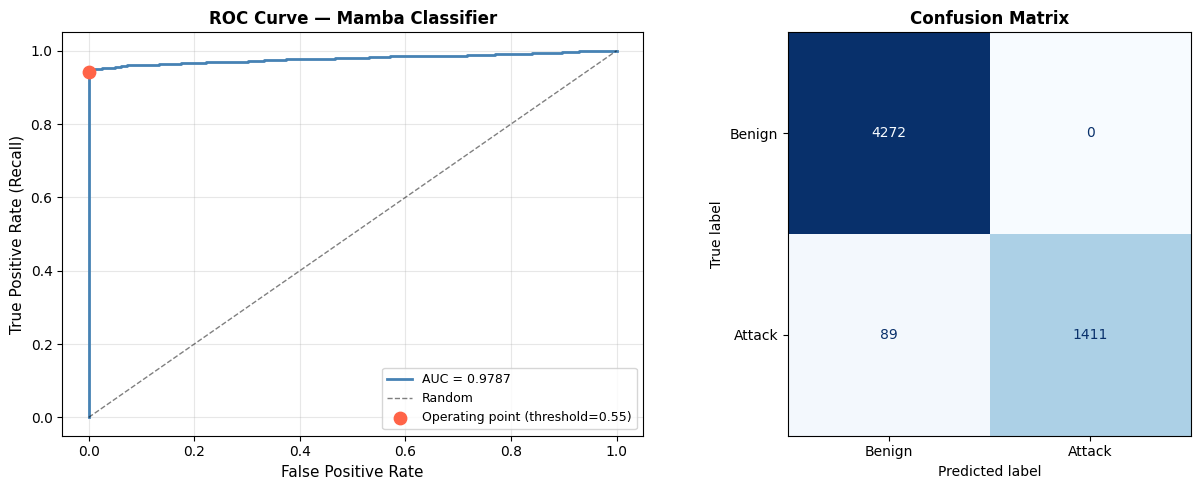

True Negatives  (benign correctly identified) : 4,272
False Positives (benign flagged as attack)    : 0  ← false alarms
False Negatives (attacks missed)              : 89  ← dangerous misses
True Positives  (attacks correctly caught)    : 1,411


In [21]:
# ── ROC Curve + Confusion Matrix ───────────────────────────────────────────
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

fpr_curve, tpr_curve, _ = roc_curve(all_labels, all_probs)
cm = confusion_matrix(all_labels, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ROC
ax1.plot(fpr_curve, tpr_curve, color='steelblue', linewidth=2,
         label=f'AUC = {metrics["auc_roc"]:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax1.scatter([metrics['fpr']], [metrics['recall']],
            color='tomato', s=80, zorder=5, label=f'Operating point (threshold={opt_thresh:.2f})')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax1.set_title('ROC Curve — Mamba Classifier', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (benign correctly identified) : {tn:,}')
print(f'False Positives (benign flagged as attack)    : {fp:,}  ← false alarms')
print(f'False Negatives (attacks missed)              : {fn:,}  ← dangerous misses')
print(f'True Positives  (attacks correctly caught)    : {tp:,}')